<a href="https://colab.research.google.com/github/siddhartha-sai-17/Gen-AI/blob/main/Employee_Policy_Assistant_%E2%80%93_Embedding_Generation_and_Semantic_Similarity_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Employee Policy Assistant: Embedding Generation and Semantic Similarity Analysis

## Problem Statement
A company is building an AI-powered Employee Policy Assistant. The policy documents have already been divided into chunks. Before storing the chunks in a Vector Database, the company wants to generate embeddings and analyze semantic similarity between employee queries and policy document chunks.

Your task is to convert document chunks into embeddings and study how embeddings capture meaning rather than exact words.

## Dataset
Use the following policy chunks:
```python
chunks = [
    "Employees receive 12 casual leaves annually.",
    "Employees receive 15 sick leaves annually.",
    "Employees may work from home twice per week.",
    "Travel expenses are reimbursed within 30 days.",
    "All employees are covered under company medical insurance."
]
```

## Task 1: Load Embedding Model

**Objective**
Load a Sentence Transformer embedding model.

**Requirements**
Use:
- `all-MiniLM-L6-v2`

**Deliverables**
Display:
- Model Name
- Embedding Dimension

In [1]:
import warnings
warnings.filterwarnings('ignore')

!pip install -U sentence-transformers > /dev/null

from sentence_transformers import SentenceTransformer

# Load the embedding model
model_name = 'all-MiniLM-L6-v2'
model = SentenceTransformer(model_name)

# Display Model Name and Embedding Dimension
print(f"Model Name: {model_name}")
print(f"Embedding Dimension: {model.get_sentence_embedding_dimension()}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model Name: all-MiniLM-L6-v2
Embedding Dimension: 384


## Task 2: Generate Embeddings

**Objective**
Convert all policy chunks into vector embeddings.

**Deliverables**
Display:
- Chunk Content
- Embedding Shape

**Example**:
```
Chunk:
Employees receive 12 casual leaves annually.
Embedding Shape:
(384,)
```

In [2]:
import numpy as np

chunks = [
    "Employees receive 12 casual leaves annually.",
    "Employees receive 15 sick leaves annually.",
    "Employees may work from home twice per week.",
    "Travel expenses are reimbursed within 30 days.",
    "All employees are covered under company medical insurance."
]

# Generate embeddings for each chunk
chunk_embeddings = model.encode(chunks)

# Display chunk content and embedding shape
print("Chunk Embeddings:")
for i, (chunk, embedding) in enumerate(zip(chunks, chunk_embeddings)):
    print(f"\nChunk {i+1}:")
    print(f"Content: {chunk}")
    print(f"Embedding Shape: {embedding.shape}")

Chunk Embeddings:

Chunk 1:
Content: Employees receive 12 casual leaves annually.
Embedding Shape: (384,)

Chunk 2:
Content: Employees receive 15 sick leaves annually.
Embedding Shape: (384,)

Chunk 3:
Content: Employees may work from home twice per week.
Embedding Shape: (384,)

Chunk 4:
Content: Travel expenses are reimbursed within 30 days.
Embedding Shape: (384,)

Chunk 5:
Content: All employees are covered under company medical insurance.
Embedding Shape: (384,)


## Task 3: Analyze Embedding Vectors

**Objective**
Understand how text becomes numerical vectors.

**Requirements**
Display:
- First 20 values of embedding vector

**Example**:
```
[0.123,
 0.451,
 -0.221,
 ...]
```

**Analysis**
Explain:
- Why embeddings contain decimal values.

In [3]:
# Display the first 20 values of the first chunk's embedding
print("First 20 values of the first chunk's embedding:")
print(chunk_embeddings[0][:20])

print("\n### Analysis: Why embeddings contain decimal values ###")
print("Embeddings contain decimal values because they represent words, phrases, or entire documents as points in a continuous, multi-dimensional vector space. These decimal values are not arbitrary; they are learned through complex neural network models during training.\n\nEach dimension in the vector space captures a different semantic or syntactic aspect of the text. The specific decimal values indicate the strength or presence of these features for that particular piece of text. For instance, if one dimension represents 'medical terms', a high positive decimal value in that dimension for a specific embedding would indicate a strong relation to medical concepts, while a negative or zero value would indicate the opposite.\n\nThis continuous representation allows for fine-grained distinctions in meaning and enables mathematical operations (like cosine similarity) to accurately measure semantic relationships between different texts. If embeddings were restricted to integers, they would lose this nuanced ability to capture meaning and similarity effectively, as the space between values would be discrete and less expressive.")

First 20 values of the first chunk's embedding:
[ 0.0618362   0.01376683  0.03366624  0.0186107   0.03135883  0.06788085
 -0.01135737 -0.01733116 -0.07070484  0.01901567  0.1098766   0.05092814
 -0.0489678  -0.04620624 -0.03665631  0.00247606 -0.06287521  0.00541349
  0.03131726 -0.07714854]

### Analysis: Why embeddings contain decimal values ###
Embeddings contain decimal values because they represent words, phrases, or entire documents as points in a continuous, multi-dimensional vector space. These decimal values are not arbitrary; they are learned through complex neural network models during training.

Each dimension in the vector space captures a different semantic or syntactic aspect of the text. The specific decimal values indicate the strength or presence of these features for that particular piece of text. For instance, if one dimension represents 'medical terms', a high positive decimal value in that dimension for a specific embedding would indicate a strong relation to medi

## Task 4: Generate Query Embeddings

**Objective**
Convert employee questions into embeddings.

**Queries**
```python
queries = [
    "How many casual leaves are allowed?",
    "Can employees work remotely?",
    "What is the travel reimbursement process?",
    "Do employees have medical insurance?"
]
```

**Deliverables**
Display:
- Query
- Embedding Shape

In [4]:
queries = [
    "How many casual leaves are allowed?",
    "Can employees work remotely?",
    "What is the travel reimbursement process?",
    "Do employees have medical insurance?"
]

# Generate embeddings for each query
query_embeddings = model.encode(queries)

# Display query and embedding shape
print("Query Embeddings:")
for i, (query, embedding) in enumerate(zip(queries, query_embeddings)):
    print(f"\nQuery {i+1}:")
    print(f"Content: {query}")
    print(f"Embedding Shape: {embedding.shape}")

Query Embeddings:

Query 1:
Content: How many casual leaves are allowed?
Embedding Shape: (384,)

Query 2:
Content: Can employees work remotely?
Embedding Shape: (384,)

Query 3:
Content: What is the travel reimbursement process?
Embedding Shape: (384,)

Query 4:
Content: Do employees have medical insurance?
Embedding Shape: (384,)


## Task 5: Semantic Similarity Analysis

**Objective**
Compare meaning between queries and policy chunks.

**Requirements**
Calculate cosine similarity between:
- Query Embeddings
- Chunk Embeddings

**Deliverables**
Display:
- Query
- Chunk
- Similarity Score

In [5]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate cosine similarity between query embeddings and chunk embeddings
similarity_matrix = cosine_similarity(query_embeddings, chunk_embeddings)

# Display the similarity scores
print("Semantic Similarity Scores (Query vs. Chunk):\n")
for i, query in enumerate(queries):
    print(f"Query: {query}")
    for j, chunk in enumerate(chunks):
        score = similarity_matrix[i][j]
        print(f"  Chunk {j+1}: {chunk}")
        print(f"  Similarity Score: {score:.4f}\n")

Semantic Similarity Scores (Query vs. Chunk):

Query: How many casual leaves are allowed?
  Chunk 1: Employees receive 12 casual leaves annually.
  Similarity Score: 0.6552

  Chunk 2: Employees receive 15 sick leaves annually.
  Similarity Score: 0.4110

  Chunk 3: Employees may work from home twice per week.
  Similarity Score: 0.1763

  Chunk 4: Travel expenses are reimbursed within 30 days.
  Similarity Score: 0.0493

  Chunk 5: All employees are covered under company medical insurance.
  Similarity Score: 0.0472

Query: Can employees work remotely?
  Chunk 1: Employees receive 12 casual leaves annually.
  Similarity Score: 0.1963

  Chunk 2: Employees receive 15 sick leaves annually.
  Similarity Score: 0.2300

  Chunk 3: Employees may work from home twice per week.
  Similarity Score: 0.4834

  Chunk 4: Travel expenses are reimbursed within 30 days.
  Similarity Score: -0.0254

  Chunk 5: All employees are covered under company medical insurance.
  Similarity Score: 0.3006

Query

## Task 6: Identify Most Similar Chunk

**Objective**
Find the chunk whose meaning is closest to the query.

**Example**
```
Query:
How many casual leaves are allowed?
Expected Match:
Employees receive 12 casual leaves annually.
```

**Deliverables**
Display:
- Query
- Most Similar Chunk
- Similarity Score

In [6]:
print("Most Similar Chunk for each Query:\n")
for i, query in enumerate(queries):
    # Find the index of the chunk with the maximum similarity score for the current query
    most_similar_chunk_index = np.argmax(similarity_matrix[i])

    # Retrieve the most similar chunk and its score
    most_similar_chunk = chunks[most_similar_chunk_index]
    max_similarity_score = similarity_matrix[i][most_similar_chunk_index]

    print(f"Query: {query}")
    print(f"  Most Similar Chunk: {most_similar_chunk}")
    print(f"  Similarity Score: {max_similarity_score:.4f}\n")

Most Similar Chunk for each Query:

Query: How many casual leaves are allowed?
  Most Similar Chunk: Employees receive 12 casual leaves annually.
  Similarity Score: 0.6552

Query: Can employees work remotely?
  Most Similar Chunk: Employees may work from home twice per week.
  Similarity Score: 0.4834

Query: What is the travel reimbursement process?
  Most Similar Chunk: Travel expenses are reimbursed within 30 days.
  Similarity Score: 0.7255

Query: Do employees have medical insurance?
  Most Similar Chunk: All employees are covered under company medical insurance.
  Similarity Score: 0.8030



## Task 7: Similar Meaning vs Different Meaning

**Objective**
Observe how embeddings capture semantics.

**Sentence Pair 1**
- `Employees receive 12 casual leaves.`
- `Workers are entitled to 12 annual leaves.`

**Sentence Pair 2**
- `Employees receive 12 casual leaves.`
- `Travel expenses are reimbursed within 30 days.`

**Deliverables**
Calculate:
- Cosine Similarity

**Analysis**
Answer:
- Why Pair 1 has higher similarity than Pair 2.

In [7]:
print("### Task 7: Similar Meaning vs Different Meaning ###\n")

sentence_pair_1 = [
    "Employees receive 12 casual leaves.",
    "Workers are entitled to 12 annual leaves."
]
sentence_pair_2 = [
    "Employees receive 12 casual leaves.",
    "Travel expenses are reimbursed within 30 days."
]

# Generate embeddings for sentence pairs
embeddings_pair_1 = model.encode(sentence_pair_1)
embeddings_pair_2 = model.encode(sentence_pair_2)

# Calculate cosine similarity for Pair 1
similarity_pair_1 = cosine_similarity([embeddings_pair_1[0]], [embeddings_pair_1[1]])[0][0]
print(f"Sentence Pair 1: '{sentence_pair_1[0]}' vs '{sentence_pair_1[1]}'")
print(f"Cosine Similarity (Pair 1): {similarity_pair_1:.4f}\n")

# Calculate cosine similarity for Pair 2
similarity_pair_2 = cosine_similarity([embeddings_pair_2[0]], [embeddings_pair_2[1]])[0][0]
print(f"Sentence Pair 2: '{sentence_pair_2[0]}' vs '{sentence_pair_2[1]}'")
print(f"Cosine Similarity (Pair 2): {similarity_pair_2:.4f}\n")

print("### Analysis: Why Pair 1 has higher similarity than Pair 2 ###")
print("Sentence Pair 1 has a significantly higher cosine similarity score than Sentence Pair 2 because the embeddings effectively capture semantic meaning rather than just lexical overlap. \n\nEven though the exact words are different (e.g., 'Employees' vs 'Workers', 'casual leaves' vs 'annual leaves', 'receive' vs 'entitled to'), the *meaning* conveyed by both sentences in Pair 1 is almost identical: both refer to the allowance of 12 yearly leaves for staff. The embedding model understands these paraphrases and maps them to very close points in the vector space.\n\nConversely, Sentence Pair 2 contains two sentences that are semantically distinct. One discusses 'casual leaves' for 'employees', while the other discusses 'travel expenses' and 'reimbursement'. Despite some common words like 'employees' (if present, though not in the provided example), their core topics and contexts are entirely different. This semantic divergence leads to their embeddings being far apart in the vector space, resulting in a much lower (or even negative) cosine similarity score.")

### Task 7: Similar Meaning vs Different Meaning ###

Sentence Pair 1: 'Employees receive 12 casual leaves.' vs 'Workers are entitled to 12 annual leaves.'
Cosine Similarity (Pair 1): 0.7710

Sentence Pair 2: 'Employees receive 12 casual leaves.' vs 'Travel expenses are reimbursed within 30 days.'
Cosine Similarity (Pair 2): 0.1750

### Analysis: Why Pair 1 has higher similarity than Pair 2 ###
Sentence Pair 1 has a significantly higher cosine similarity score than Sentence Pair 2 because the embeddings effectively capture semantic meaning rather than just lexical overlap. 

Even though the exact words are different (e.g., 'Employees' vs 'Workers', 'casual leaves' vs 'annual leaves', 'receive' vs 'entitled to'), the *meaning* conveyed by both sentences in Pair 1 is almost identical: both refer to the allowance of 12 yearly leaves for staff. The embedding model understands these paraphrases and maps them to very close points in the vector space.

Conversely, Sentence Pair 2 contains two

## Task 8: Embedding Visualization

**Objective**
Visualize embeddings using PCA or t-SNE.

**Deliverables**
Plot:
- Chunk Embeddings
- Query Embeddings

**Analysis**
Explain:
- Why semantically similar texts appear closer together.

### Task 8: Embedding Visualization ###



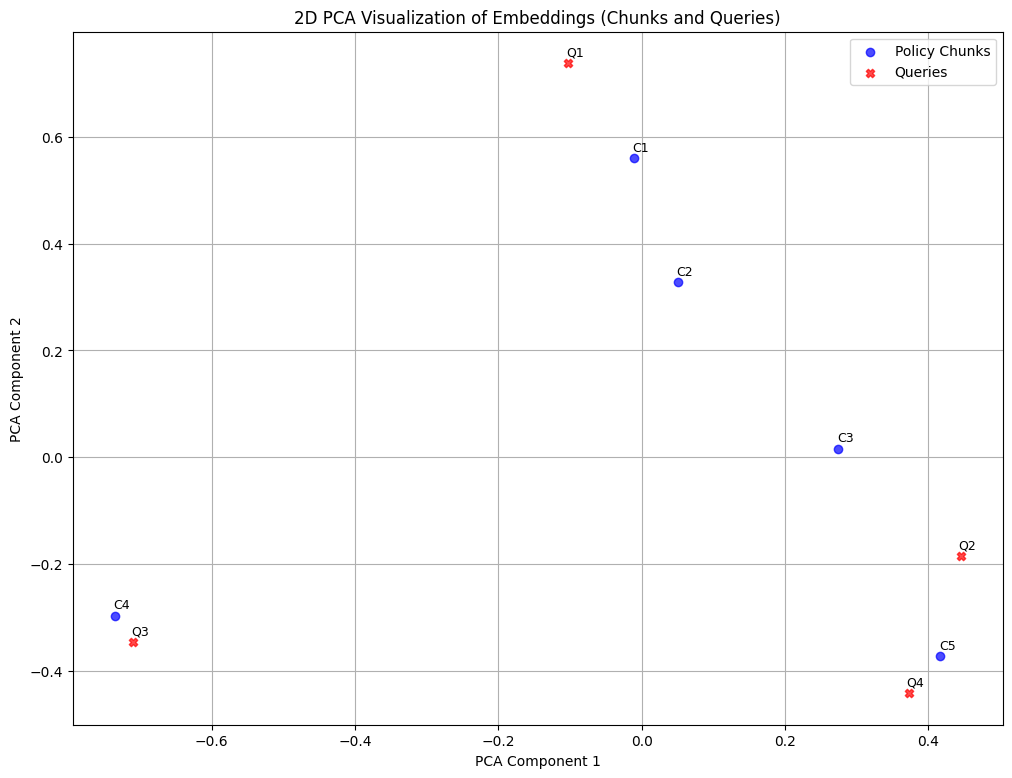


### Analysis: Why semantically similar texts appear closer together ###
In the PCA visualization, you'll observe that semantically similar texts (e.g., a query about casual leaves and the policy chunk regarding casual leaves) appear closer together in the 2D space. This is a direct consequence of how embedding models are trained.

Embedding models are designed to map text with similar meanings to nearby points in a high-dimensional vector space. When dimensionality reduction techniques like PCA are applied, they try to preserve as much of this proximity information as possible in a lower-dimensional space. Therefore, if two pieces of text are semantically similar, their high-dimensional embeddings will have a small 'distance' (e.g., high cosine similarity), and this small distance will generally be maintained in the reduced 2D representation.

This clustering of similar concepts demonstrates the effectiveness of embeddings in capturing the underlying meaning of text, making them incre

In [8]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print("### Task 8: Embedding Visualization ###\n")

# Combine chunk and query embeddings for dimensionality reduction
all_embeddings = np.vstack((chunk_embeddings, query_embeddings))

# Apply PCA to reduce dimensions to 2 for visualization
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(all_embeddings)

# Separate the reduced embeddings back into chunks and queries
reduced_chunk_embeddings = reduced_embeddings[:len(chunks)]
reduced_query_embeddings = reduced_embeddings[len(chunks):]

# Plotting the embeddings
plt.figure(figsize=(12, 9))

# Plot chunk embeddings
plt.scatter(reduced_chunk_embeddings[:, 0], reduced_chunk_embeddings[:, 1], c='blue', label='Policy Chunks', alpha=0.7)
for i, txt in enumerate(chunks):
    plt.annotate(f'C{i+1}', (reduced_chunk_embeddings[i, 0], reduced_chunk_embeddings[i, 1]), textcoords="offset points", xytext=(5,5), ha='center', fontsize=9)

# Plot query embeddings
plt.scatter(reduced_query_embeddings[:, 0], reduced_query_embeddings[:, 1], c='red', label='Queries', alpha=0.7, marker='X')
for i, txt in enumerate(queries):
    plt.annotate(f'Q{i+1}', (reduced_query_embeddings[i, 0], reduced_query_embeddings[i, 1]), textcoords="offset points", xytext=(5,5), ha='center', fontsize=9)

plt.title('2D PCA Visualization of Embeddings (Chunks and Queries)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid(True)
plt.show()

print("\n### Analysis: Why semantically similar texts appear closer together ###")
print("In the PCA visualization, you'll observe that semantically similar texts (e.g., a query about casual leaves and the policy chunk regarding casual leaves) appear closer together in the 2D space. This is a direct consequence of how embedding models are trained.\n\nEmbedding models are designed to map text with similar meanings to nearby points in a high-dimensional vector space. When dimensionality reduction techniques like PCA are applied, they try to preserve as much of this proximity information as possible in a lower-dimensional space. Therefore, if two pieces of text are semantically similar, their high-dimensional embeddings will have a small 'distance' (e.g., high cosine similarity), and this small distance will generally be maintained in the reduced 2D representation.\n\nThis clustering of similar concepts demonstrates the effectiveness of embeddings in capturing the underlying meaning of text, making them incredibly useful for tasks like information retrieval, semantic search, and clustering, where understanding context and meaning beyond exact keyword matches is crucial.")